       Stage  Count
0   Visitors   5000
1      Leads   1200
2  Prospects    600
3  Customers    300

Conversion Rates:
        Stage  Count  Conversion_Rate (%)
0   Visitors   5000                100.0
1      Leads   1200                -76.0
2  Prospects    600                -50.0
3  Customers    300                -50.0


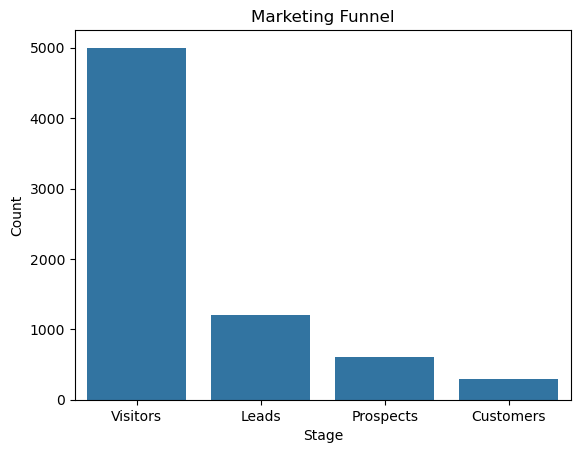

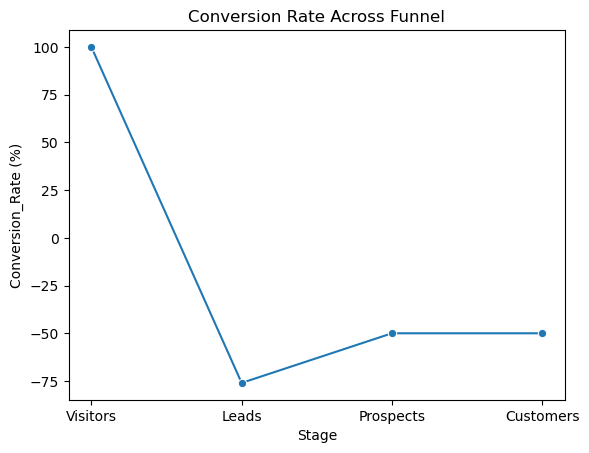


Drop-Off Analysis:
        Stage  Count  Conversion_Rate (%)  Drop_Off
0   Visitors   5000                100.0       0.0
1      Leads   1200                -76.0    3800.0
2  Prospects    600                -50.0     600.0
3  Customers    300                -50.0     300.0


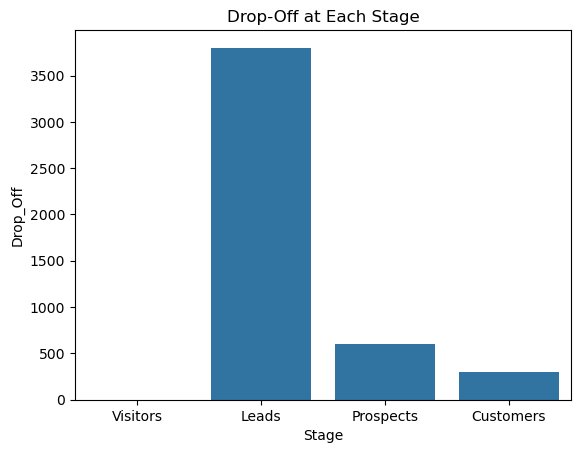


Worst Performing Stage (Highest Drop): Leads
Best Conversion Stage: Visitors

Channel Performance:
         Channel  Leads  Customers  Conversion (%)
0  Social Media    300         80       26.666667
1         Email    400        150       37.500000
2           Ads    350        100       28.571429
3       Organic    150         70       46.666667


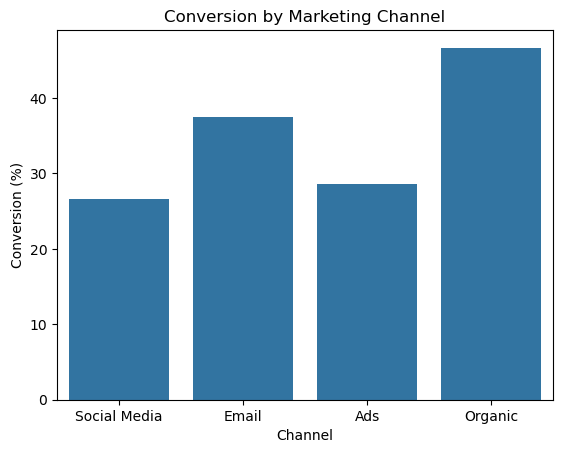

In [3]:
# ================================
# 🔹 IMPORT LIBRARIES
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 🔹 CREATE SAMPLE DATA (if no dataset)
# ================================
data = {
    "Stage": ["Visitors", "Leads", "Prospects", "Customers"],
    "Count": [5000, 1200, 600, 300]
}

df = pd.DataFrame(data)

print(df)

# ================================
# 🔹 CONVERSION RATES
# ================================
df["Conversion_Rate (%)"] = df["Count"].pct_change() * 100
df["Conversion_Rate (%)"] = df["Conversion_Rate (%)"].fillna(100)

print("\nConversion Rates:\n", df)

# ================================
# 🔹 FUNNEL VISUALIZATION
# ================================
plt.figure()
sns.barplot(x="Stage", y="Count", data=df)
plt.title("Marketing Funnel")
plt.show()

# ================================
# 🔹 CONVERSION RATE VISUALIZATION
# ================================
plt.figure()
sns.lineplot(x="Stage", y="Conversion_Rate (%)", marker='o', data=df)
plt.title("Conversion Rate Across Funnel")
plt.show()

# ================================
# 🔹 DROP-OFF ANALYSIS
# ================================
df["Drop_Off"] = df["Count"].shift(1) - df["Count"]
df["Drop_Off"] = df["Drop_Off"].fillna(0)

print("\nDrop-Off Analysis:\n", df)

# ================================
# 🔹 DROP-OFF VISUALIZATION
# ================================
plt.figure()
sns.barplot(x="Stage", y="Drop_Off", data=df)
plt.title("Drop-Off at Each Stage")
plt.show()

# ================================
# 🔹 BEST & WORST STAGE
# ================================
worst_stage = df.loc[df["Drop_Off"].idxmax(), "Stage"]
best_stage = df.loc[df["Conversion_Rate (%)"].idxmax(), "Stage"]

print(f"\nWorst Performing Stage (Highest Drop): {worst_stage}")
print(f"Best Conversion Stage: {best_stage}")

# ================================
# 🔹 BONUS: CHANNEL PERFORMANCE
# ================================
channel_data = {
    "Channel": ["Social Media", "Email", "Ads", "Organic"],
    "Leads": [300, 400, 350, 150],
    "Customers": [80, 150, 100, 70]
}

df_channel = pd.DataFrame(channel_data)

# Conversion per channel
df_channel["Conversion (%)"] = (df_channel["Customers"] / df_channel["Leads"]) * 100

print("\nChannel Performance:\n", df_channel)

# Visualization
plt.figure()
sns.barplot(x="Channel", y="Conversion (%)", data=df_channel)
plt.title("Conversion by Marketing Channel")
plt.show()